# Introduction

Goal. Build a model to predict stroke, optimizing for maximum sensitivity (Recall). In medical tasks it is especially important to minimize missed positive cases, so Recall is the main evaluation metric. Excessive drop in Precision is also undesirable because it increases false alarms and the workload for clinicians.

The dataset contains clinical patient features and is characterized by significant noise and a strong class imbalance. To increase model robustness and predictive power we use ensemble learning (stacking), which allows combining strengths of multiple algorithms and improving the final decision quality.

# Imports and data loading

In [173]:
import warnings
warnings.simplefilter(action='ignore', category=(UserWarning, FutureWarning, RuntimeWarning, DeprecationWarning))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, precision_recall_curve, PrecisionRecallDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
import joblib

from catboost import CatBoostClassifier

In [174]:
df = pd.read_csv("/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [14]:
df.shape

(5110, 12)

In [15]:
print("There is {} duplicated values in data frame".format(df.duplicated().sum()))

There is 0 duplicated values in data frame


In [16]:
df.columns = df.columns.str.capitalize()
df

,Id,Gender,Age,Hypertension,Heart_disease,Ever_married,Work_type,Residence_type,Avg_glucose_level,Bmi,Smoking_status,Stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [6]:
df.nunique()


id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

In [274]:
df.describe()

,Age,Hypertension,Heart_disease,Avg_glucose_level,Bmi,Stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


## Missing values

In [50]:
df.isnull().sum().to_frame().rename(columns={0:"Number of Missing Values"})

,Number of Missing Values
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [49]:
X = df.drop("stroke", axis=1)
y = df["stroke"]


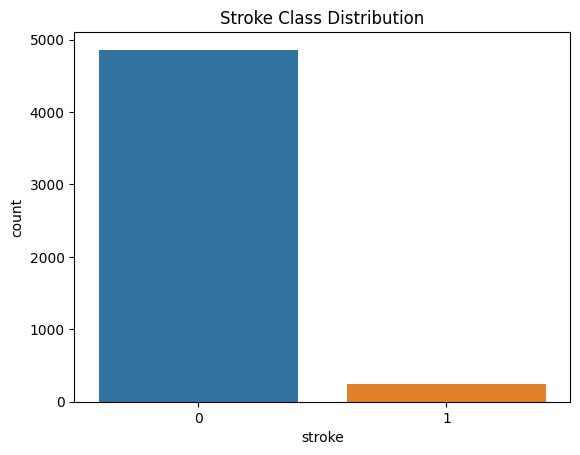

In [39]:
sns.countplot(x=y)
plt.title("Stroke Class Distribution")
plt.show()


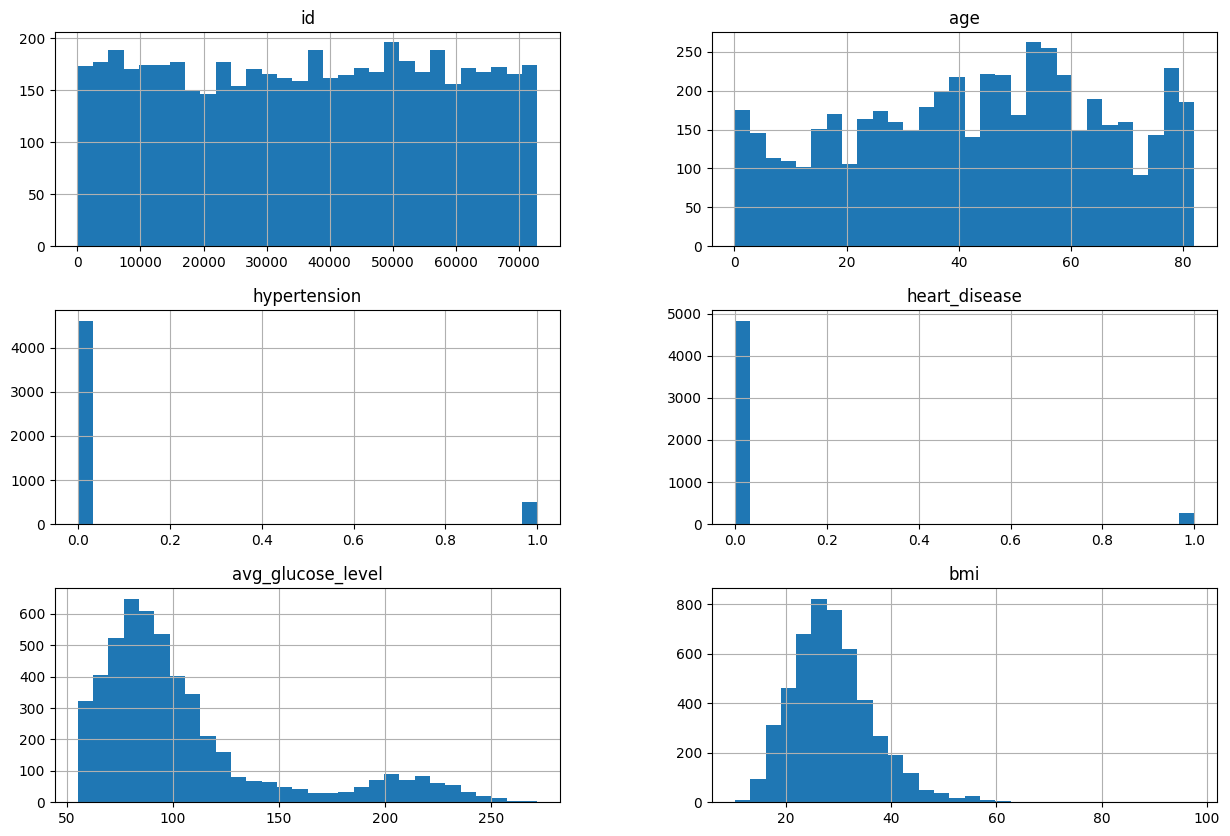

In [67]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

X[num_cols].hist(figsize=(15,10), bins=30)
plt.show()


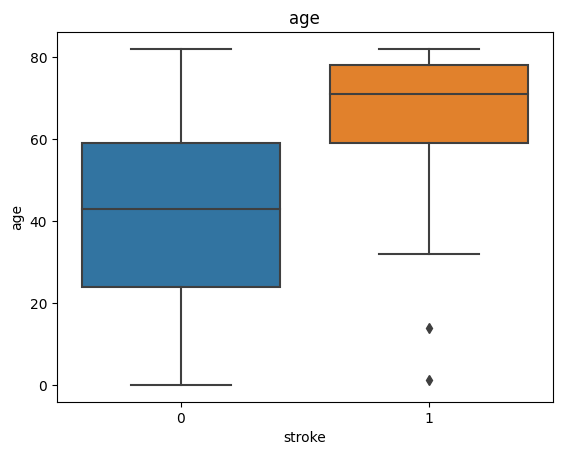

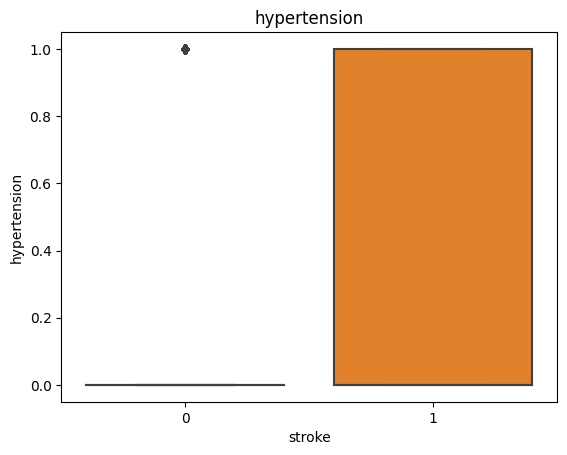

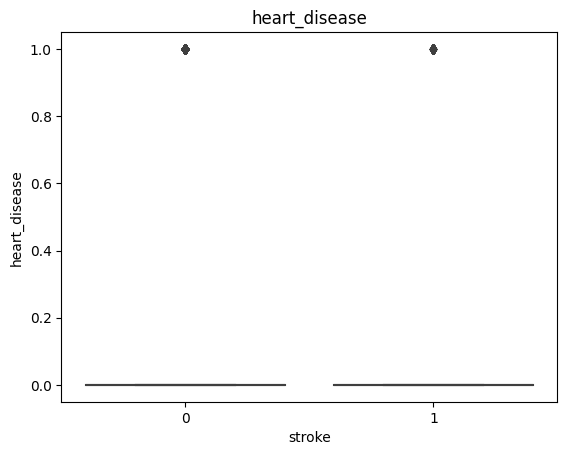

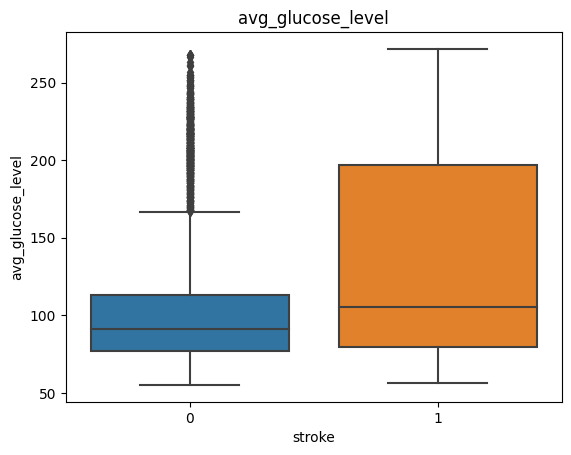

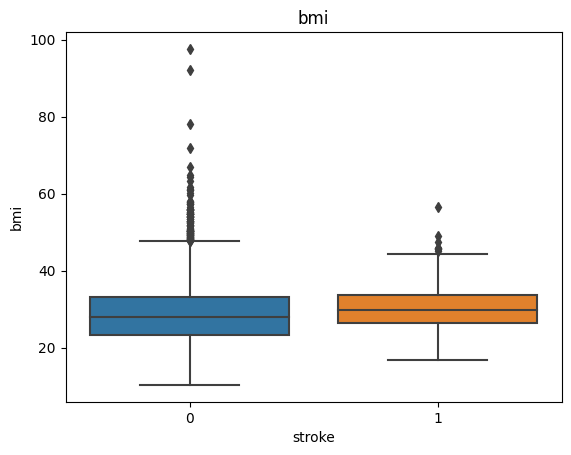

In [328]:
for col in num_cols:
    sns.boxplot(x=y, y=X[col])
    plt.title(col)
    plt.show()


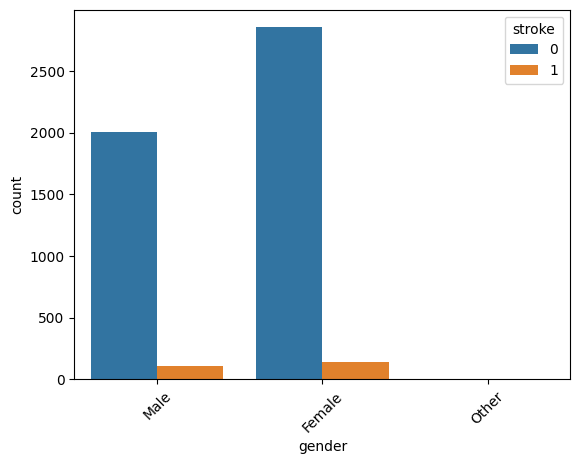

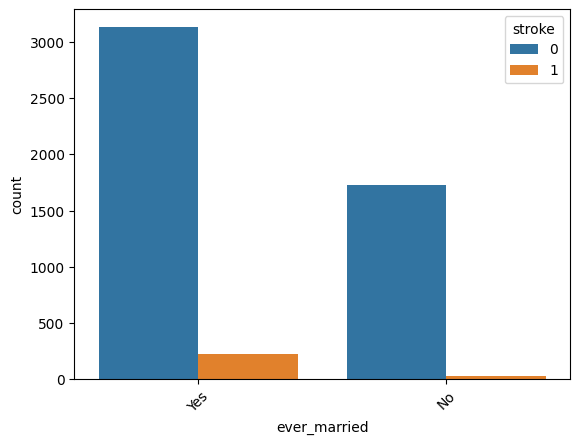

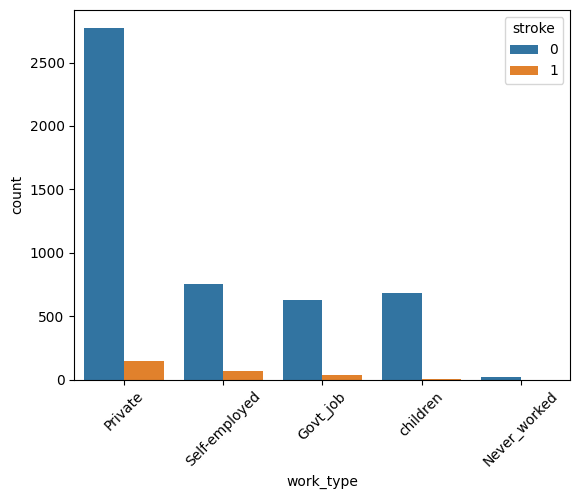

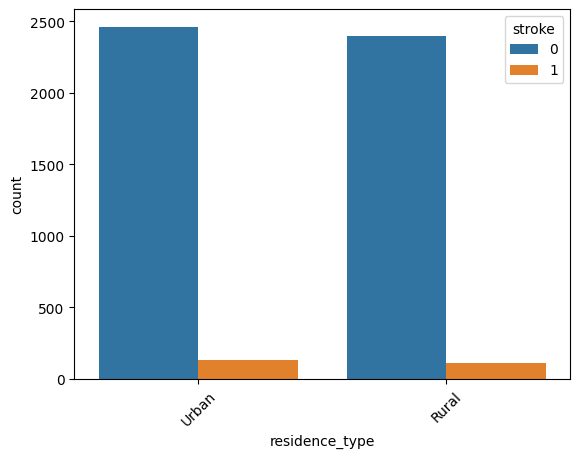

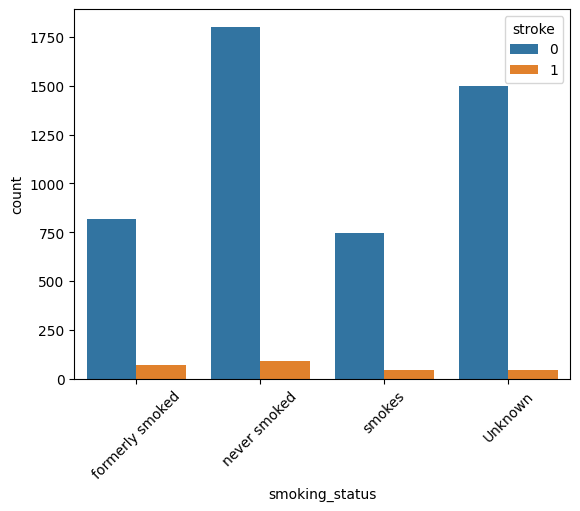

In [69]:
cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    sns.countplot(x=col, hue=y, data=df)
    plt.xticks(rotation=45)
    plt.show()


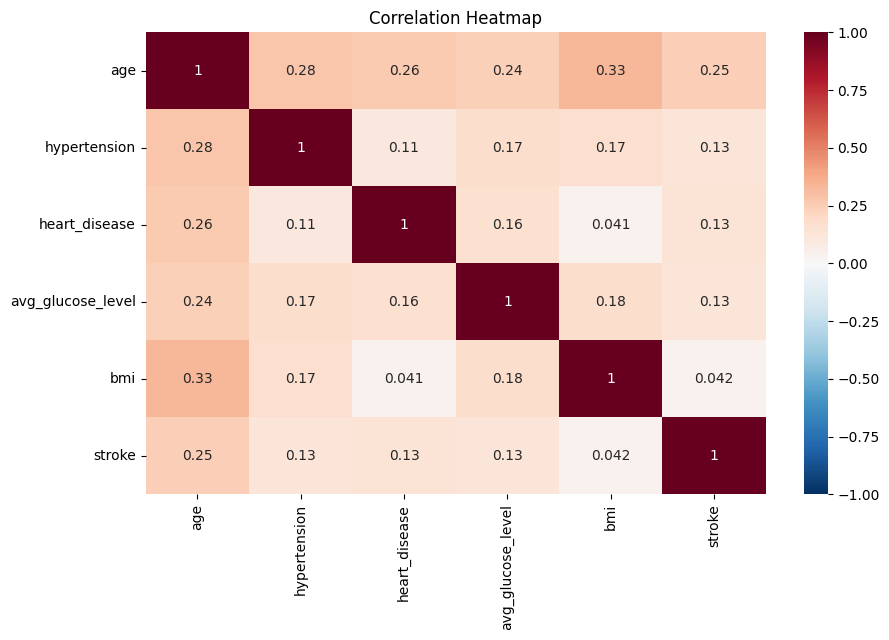

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# select numeric columns
num_cols = df.select_dtypes(include='number').columns.drop('id')

plt.figure(figsize=(10,6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="RdBu_r",   
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap")
plt.show()



In [189]:
df.columns = df.columns.str.lower()


In [191]:
# Numeric columns
num_cols = df.select_dtypes(include='number').columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

numeric_features = num_cols
categorical_features = cat_cols
print("Numeric Features:", numeric_features.tolist())
print("Categorical Features:", categorical_features.tolist())


Numeric Features: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
Categorical Features: ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']


In [233]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['gender', 'ever_married', 'work_type', 'residence_type',
       'smoking_status'],
      dtype='object'))])


In [235]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())



(4088, 10)
(1022, 10)
stroke
0    3889
1     199
Name: count, dtype: int64


In [ ]:
MODEL BUILDING (3 REQUIRED MODELS)

In [237]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
Pipeline(steps=[('preprocessor', ColumnTransformer(...)),
                ('model', LogisticRegression(...))])


Pipeline(steps=[('preprocessor', ColumnTransformer(transformers=Ellipsis)),
                ('model', LogisticRegression(penalty=Ellipsis))])

In [243]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X = df.drop(columns=['stroke', 'id'])
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])
rf.fit(X_train, y_train)
y_prob = rf.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.95      0.98      0.97       972
           1       0.21      0.10      0.14        50

    accuracy                           0.94      1022
   macro avg       0.58      0.54      0.55      1022
weighted avg       0.92      0.94      0.93      1022

ROC-AUC: 0.7704629629629629


In [260]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

svc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, class_weight="balanced"))
])
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
y_prob = svc.predict_proba(X_test)[:, 1]

y_pred[:10], y_prob[:10]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


Accuracy: 0.7622309197651663
ROC-AUC: 0.7983333333333333
              precision    recall  f1-score   support

           0       0.98      0.77      0.86       972
           1       0.13      0.70      0.22        50

    accuracy                           0.76      1022
   macro avg       0.56      0.73      0.54      1022
weighted avg       0.94      0.76      0.83      1022



In [ ]:
CROSS-VALIDATION

In [259]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    log_reg,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)
print("ARRAY:", np.round(scores, 4))
print("Mean ROC-AUC:", round(scores.mean(), 4))
print("Std ROC-AUC:", round(scores.std(), 4))

ARRAY: [0.8291 0.8249 0.8597 0.8644 0.8064]
Mean ROC-AUC: 0.8369
Std ROC-AUC: 0.0219


In [ ]:
HYPERPARAMETER OPTIMIZATION (GRID SEARCH)

In [263]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 50],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']  
}
grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)
print("Best ROC-AUC:", round(grid.best_score_, 4))
print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best ROC-AUC: 0.8404
Best Parameters: {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


In [ ]:
Random Forest Optimization

In [261]:
from sklearn.model_selection import GridSearchCV

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

rf_grid.best_params_, rf_grid.best_score_


Fitting 5 folds for each of 12 candidates, totalling 60 fits


({'model__max_depth': None,
  'model__min_samples_split': 5,
  'model__n_estimators': 200},
 0.8282673789711066)

In [ ]:
SVC Optimization

In [337]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

svc_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),   
    ("model", SVC(probability=True, random_state=42))
])
svc_params = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["rbf", "linear"]
}
from sklearn.model_selection import GridSearchCV

svc_grid = GridSearchCV(
    estimator=svc_pipeline,   
    param_grid=svc_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

svc_grid.fit(X_train, y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'hypertension',
                                                                          'heart_disease',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'ever_married',
                                                                          'work_type',
                                                                          'residence_type',
                                                                          'smoking_status'])])),
                                       ('model',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__kernel': ['rbf', 'linear']},
             scoring='roc_auc')

In [ ]:
MODEL EVALUATION

In [283]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_grid.best_estimator_,
    "SVC": svc_grid.best_estimator_
}
for name, model in models.items():
    print(f"{name}: {model}")


Logistic Regression: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease',
                                                   'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                          

In [329]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.745597,0.137931,0.80,0.235294,0.843663
1,Random Forest,0.948141,0.333333,0.06,0.101695,0.791471
2,SVC,0.728963,0.132686,0.82,0.228412,0.843889


In [ ]:
FEATURE IMPORTANCE

In [301]:
import pandas as pd

rf_estimator = rf_model.named_steps['model']
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

importances = rf_estimator.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Show top 10
feat_imp.head(10)


,Feature,Importance
0,num__age,0.375025
3,num__avg_glucose_level,0.180650
4,num__bmi,0.169872
1,num__hypertension,0.031672
8,cat__ever_married_No,0.022161
9,cat__ever_married_Yes,0.021129
2,num__heart_disease,0.019950
19,cat__smoking_status_never smoked,0.018677
13,cat__work_type_Self-employed,0.017674
12,cat__work_type_Private,0.016441


In [304]:
import joblib

joblib.dump(rf_model, "stroke_best_model.pkl")


['stroke_best_model.pkl']

In [330]:
import pandas as pd
import joblib

loaded_model = joblib.load("stroke_best_model.pkl")
new_data = pd.DataFrame({
    "age": [67],
    "hypertension": [1],
    "heart_disease": [0],
    "avg_glucose_level": [228.69],
    "bmi": [36.6],
    "gender": ["Male"],
    "ever_married": ["Yes"],
    "work_type": ["Private"],
    "residence_type": ["Urban"],   
    "smoking_status": ["formerly smoked"]
})
prediction = loaded_model.predict(new_data)
probability = loaded_model.predict_proba(new_data)[:, 1]

print("Prediction (0 = No Stroke, 1 = Stroke):", prediction[0])
print("Stroke Probability:", round(probability[0], 4))


Prediction (0 = No Stroke, 1 = Stroke): 0
Stroke Probability: 0.1667
